In [26]:
from astropy.io import fits
from pprint import pprint
import numpy as np
import Corrfunc
from Corrfunc.mocks import DDsmu_mocks
from astropy.cosmology import Planck18
import astropy.units as u
import matplotlib.pyplot as plt
from pycorr import TwoPointCorrelationFunction
import treecorr
import pandas as pd
from pycorr import KMeansSubsampler
from sklearn import cluster
binfile_sepa = np.linspace(20, 200, 46)
s = np.sqrt(binfile_sepa[:-1] * binfile_sepa[1:])

In [64]:
#paper data
line1 = pd.read_csv("/data/honke/ell0_line_08_11.csv", header=None)
line1.columns = ["x", "y"]
cen1 = pd.read_csv("/data/honke/ell0_center_08_11.csv", header=None)
cen1.columns = ["x", "y"]
up1 = pd.read_csv("/data/honke/ell0_upper_08_11.csv", header=None)
up1.columns = ["x", "y"]
low1 = pd.read_csv("/data/honke/ell0_lower_08_11.csv", header=None)
low1.columns = ["x", "y"]
x1 = cen1["x"]
y1 = cen1["y"]
yerr_up1 = up1["y"] - y1
yerr_lo1 = y1- low1["y"]

line2 = pd.read_csv("/data/honke/ell0_line_11_16.csv", header=None)
line2.columns = ["x", "y"]
cen2 = pd.read_csv("/data/honke/ell0_center_11_16.csv", header=None)
cen2.columns = ["x", "y"]
up2 = pd.read_csv("/data/honke/ell0_upper_11_16.csv", header=None)
up2.columns = ["x", "y"]
low2 = pd.read_csv("/data/honke/ell0_lower_11_16.csv", header=None)
low2.columns = ["x", "y"]
x2 = cen2["x"]
y2 = cen2["y"]
yerr_up2 = up2["y"] - y2
yerr_lo2 = y2- low2["y"]

## DDRR

### v2

In [53]:
DD_NGC_1_v2 = np.load("/data/honke/DD_NGC_08_11_v2.npy")
DR_NGC_1_v2 = np.load("/data/honke/DR_NGC_08_11_v2.npy")
RR_NGC_1_v2 = np.load("/data/honke/RR_NGC_08_11_v2.npy")
DD_SGC_1_v2 = np.load("/data/honke/DD_SGC_08_11_v2.npy")
DR_SGC_1_v2 = np.load("/data/honke/DR_SGC_08_11_v2.npy")
RR_SGC_1_v2 = np.load("/data/honke/RR_SGC_08_11_v2.npy")

DD_NGC_2_v2 = np.load("/data/honke/DD_NGC_11_16_v2.npy")
DR_NGC_2_v2 = np.load("/data/honke/DR_NGC_11_16_v2.npy")
RR_NGC_2_v2 = np.load("/data/honke/RR_NGC_11_16_v2.npy")
DD_SGC_2_v2 = np.load("/data/honke/DD_SGC_11_16_v2.npy")
DR_SGC_2_v2 = np.load("/data/honke/DR_SGC_11_16_v2.npy")
RR_SGC_2_v2 = np.load("/data/honke/RR_SGC_11_16_v2.npy")

wD_NGC_1_v2 = np.load("/data/honke/wD_NGC_08_11_v2.npy")
wD_NGC_2_v2 = np.load("/data/honke/wD_NGC_11_16_v2.npy")
wD_SGC_1_v2 = np.load("/data/honke/wD_SGC_08_11_v2.npy")
wD_SGC_2_v2 = np.load("/data/honke/wD_SGC_11_16_v2.npy")
wR_NGC_1_v2 = np.load("/data/honke/wR_NGC_08_11_v2.npy")
wR_NGC_2_v2 = np.load("/data/honke/wR_NGC_11_16_v2.npy")
wR_SGC_1_v2 = np.load("/data/honke/wR_SGC_08_11_v2.npy")
wR_SGC_2_v2 = np.load("/data/honke/wR_SGC_11_16_v2.npy")

In [54]:
DD_NGCw_1_v2 = DD_NGC_1_v2["npairs"] * DD_NGC_1_v2["weightavg"]
DR_NGCw_1_v2 = DR_NGC_1_v2["npairs"] * DR_NGC_1_v2["weightavg"]
RR_NGCw_1_v2 = RR_NGC_1_v2["npairs"] * RR_NGC_1_v2["weightavg"]
DD_SGCw_1_v2 = DD_SGC_1_v2["npairs"] * DD_SGC_1_v2["weightavg"]
DR_SGCw_1_v2 = DR_SGC_1_v2["npairs"] * DR_SGC_1_v2["weightavg"]
RR_SGCw_1_v2 = RR_SGC_1_v2["npairs"] * RR_SGC_1_v2["weightavg"]
DD_NSw_1_v2 = DD_NGCw_1_v2 + DD_SGCw_1_v2
DR_NSw_1_v2 = DR_NGCw_1_v2 + DR_SGCw_1_v2
RR_NSw_1_v2 = RR_NGCw_1_v2 + RR_SGCw_1_v2

DD_NGCw_2_v2 = DD_NGC_2_v2["npairs"] * DD_NGC_2_v2["weightavg"]
DR_NGCw_2_v2 = DR_NGC_2_v2["npairs"] * DR_NGC_2_v2["weightavg"]
RR_NGCw_2_v2 = RR_NGC_2_v2["npairs"] * RR_NGC_2_v2["weightavg"]
DD_SGCw_2_v2 = DD_SGC_2_v2["npairs"] * DD_SGC_2_v2["weightavg"]
DR_SGCw_2_v2 = DR_SGC_2_v2["npairs"] * DR_SGC_2_v2["weightavg"]
RR_SGCw_2_v2 = RR_SGC_2_v2["npairs"] * RR_SGC_2_v2["weightavg"]
DD_NSw_2_v2 = DD_NGCw_2_v2 + DD_SGCw_2_v2
DR_NSw_2_v2 = DR_NGCw_2_v2 + DR_SGCw_2_v2
RR_NSw_2_v2 = RR_NGCw_2_v2 + RR_SGCw_2_v2

In [55]:
SD_NS_1_v2 = np.sum(wD_NGC_1_v2) + np.sum(wD_SGC_1_v2)
SR_NS_1_v2 = np.sum(wR_NGC_1_v2) + np.sum(wR_SGC_1_v2)   
DD_NSn_1_v2 = DD_NSw_1_v2 / (SD_NS_1_v2 * SD_NS_1_v2)
RR_NSn_1_v2 = RR_NSw_1_v2 / (SR_NS_1_v2 * SR_NS_1_v2)
DR_NSn_1_v2 = DR_NSw_1_v2 / (SD_NS_1_v2 * SR_NS_1_v2)

xi_smu_NS_1_v2 = (DD_NSn_1_v2 - 2*DR_NSn_1_v2 + RR_NSn_1_v2) / RR_NSn_1_v2

SD_NS_2_v2 = np.sum(wD_NGC_2_v2) + np.sum(wD_SGC_2_v2)
SR_NS_2_v2 = np.sum(wR_NGC_2_v2) + np.sum(wR_SGC_2_v2)   
DD_NSn_2_v2 = DD_NSw_2_v2 / (SD_NS_2_v2 * SD_NS_2_v2)
RR_NSn_2_v2 = RR_NSw_2_v2 / (SR_NS_2_v2 * SR_NS_2_v2)
DR_NSn_2_v2 = DR_NSw_2_v2 / (SD_NS_2_v2 * SR_NS_2_v2)

xi_smu_NS_2_v2 = (DD_NSn_2_v2 - 2*DR_NSn_2_v2 + RR_NSn_2_v2) / RR_NSn_2_v2

xi_smu_2d_NS_1_v2 = xi_smu_NS_1_v2.reshape(45, 20)
xi_mono_NS_1_v2 = xi_smu_2d_NS_1_v2.mean(axis=1)
xi_smu_2d_NS_2_v2 = xi_smu_NS_2_v2.reshape(45, 20)
xi_mono_NS_2_v2 = xi_smu_2d_NS_2_v2.mean(axis=1)

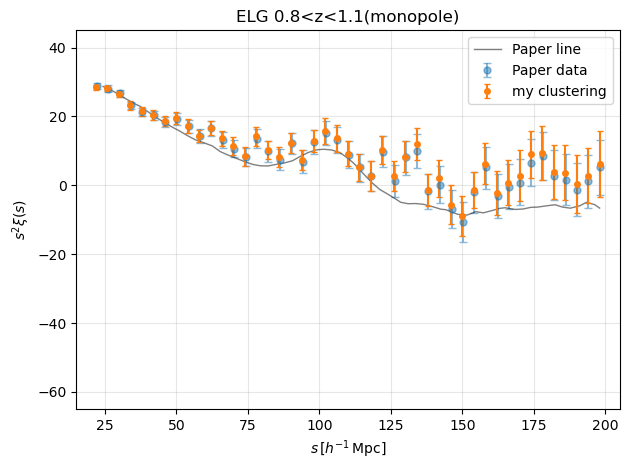

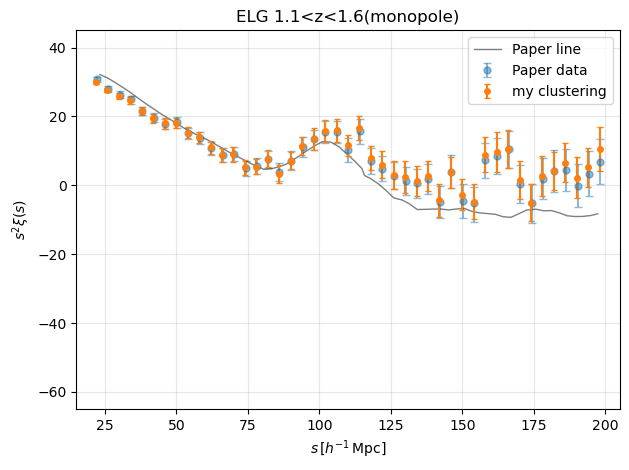

In [56]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_1_v2, yerr=s**2 * err1_v2,
    fmt="o", ms=4, capsize=2,
    label="my clustering"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_2_v2, yerr=s**2 * err2_v2,
    fmt="o", ms=4, capsize=2,
    label="my clustering"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

### v1

In [29]:
DD_NGC_1 = np.load("/data/honke/DD_NGC_08_11.npy")
DR_NGC_1 = np.load("/data/honke/DR_NGC_08_11.npy")
RR_NGC_1 = np.load("/data/honke/RR_NGC_08_11.npy")
DD_SGC_1 = np.load("/data/honke/DD_SGC_08_11.npy")
DR_SGC_1 = np.load("/data/honke/DR_SGC_08_11.npy")
RR_SGC_1 = np.load("/data/honke/RR_SGC_08_11.npy")

DD_NGC_2 = np.load("/data/honke/DD_NGC_11_16.npy")
DR_NGC_2 = np.load("/data/honke/DR_NGC_11_16.npy")
RR_NGC_2 = np.load("/data/honke/RR_NGC_11_16.npy")
DD_SGC_2 = np.load("/data/honke/DD_SGC_11_16.npy")
DR_SGC_2 = np.load("/data/honke/DR_SGC_11_16.npy")
RR_SGC_2 = np.load("/data/honke/RR_SGC_11_16.npy")

wD_NGC_1 = np.load("/data/honke/wD_NGC_08_11.npy")
wD_NGC_2 = np.load("/data/honke/wD_NGC_11_16.npy")
wD_SGC_1 = np.load("/data/honke/wD_SGC_08_11.npy")
wD_SGC_2 = np.load("/data/honke/wD_SGC_11_16.npy")
wR_NGC_1 = np.load("/data/honke/wR_NGC_08_11.npy")
wR_NGC_2 = np.load("/data/honke/wR_NGC_11_16.npy")
wR_SGC_1 = np.load("/data/honke/wR_SGC_08_11.npy")
wR_SGC_2 = np.load("/data/honke/wR_SGC_11_16.npy")

In [30]:
DD_NGCw_1 = DD_NGC_1["npairs"] * DD_NGC_1["weightavg"]
DR_NGCw_1 = DR_NGC_1["npairs"] * DR_NGC_1["weightavg"]
RR_NGCw_1 = RR_NGC_1["npairs"] * RR_NGC_1["weightavg"]
DD_SGCw_1 = DD_SGC_1["npairs"] * DD_SGC_1["weightavg"]
DR_SGCw_1 = DR_SGC_1["npairs"] * DR_SGC_1["weightavg"]
RR_SGCw_1 = RR_SGC_1["npairs"] * RR_SGC_1["weightavg"]
DD_NSw_1 = DD_NGCw_1 + DD_SGCw_1
DR_NSw_1 = DR_NGCw_1 + DR_SGCw_1
RR_NSw_1 = RR_NGCw_1+ RR_SGCw_1

DD_NGCw_2 = DD_NGC_2["npairs"] * DD_NGC_2["weightavg"]
DR_NGCw_2 = DR_NGC_2["npairs"] * DR_NGC_2["weightavg"]
RR_NGCw_2 = RR_NGC_2["npairs"] * RR_NGC_2["weightavg"]
DD_SGCw_2 = DD_SGC_2["npairs"] * DD_SGC_2["weightavg"]
DR_SGCw_2 = DR_SGC_2["npairs"] * DR_SGC_2["weightavg"]
RR_SGCw_2 = RR_SGC_2["npairs"] * RR_SGC_2["weightavg"]
DD_NSw_2 = DD_NGCw_2 + DD_SGCw_2
DR_NSw_2 = DR_NGCw_2 + DR_SGCw_2
RR_NSw_2 = RR_NGCw_2+ RR_SGCw_2

In [33]:
SD_NS_1 = np.sum(wD_NGC_1) + np.sum(wD_SGC_1)
SR_NS_1 = np.sum(wR_NGC_1) + np.sum(wR_SGC_1)   
DD_NSn_1 = DD_NSw_1 / (SD_NS_1 * SD_NS_1)
RR_NSn_1 = RR_NSw_1 / (SR_NS_1 * SR_NS_1)
DR_NSn_1 = DR_NSw_1 / (SD_NS_1 * SR_NS_1)

xi_smu_NS_1 = (DD_NSn_1 - 2*DR_NSn_1 + RR_NSn_1) / RR_NSn_1

SD_NS_2 = np.sum(wD_NGC_2) + np.sum(wD_SGC_2)
SR_NS_2 = np.sum(wR_NGC_2) + np.sum(wR_SGC_2)   
DD_NSn_2 = DD_NSw_2 / (SD_NS_2 * SD_NS_2)
RR_NSn_2 = RR_NSw_2 / (SR_NS_2 * SR_NS_2)
DR_NSn_2 = DR_NSw_2 / (SD_NS_2 * SR_NS_2)

xi_smu_NS_2 = (DD_NSn_2 - 2*DR_NSn_2 + RR_NSn_2) / RR_NSn_2

xi_smu_2d_NS_1 = xi_smu_NS_1.reshape(45, 20)
xi_mono_NS_1 = xi_smu_2d_NS_1.mean(axis=1)
xi_smu_2d_NS_2 = xi_smu_NS_2.reshape(45, 20)
xi_mono_NS_2 = xi_smu_2d_NS_2.mean(axis=1)

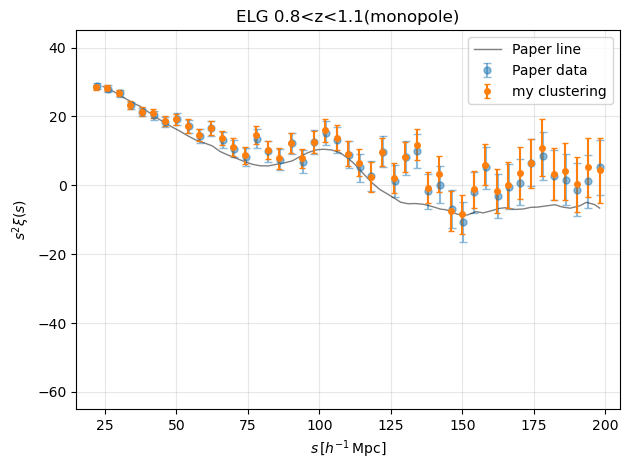

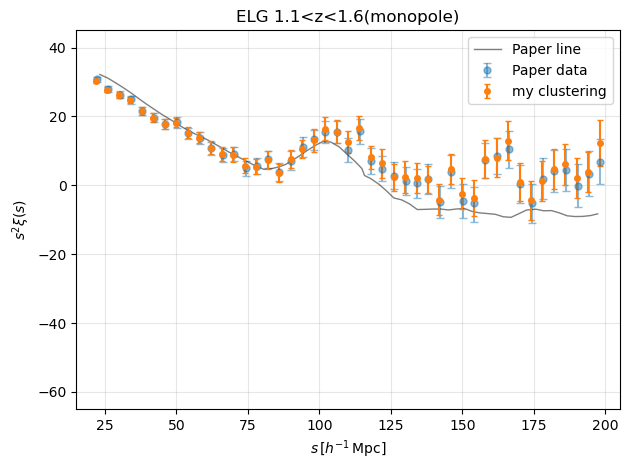

In [37]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_1, yerr=s**2 * err1,
    fmt="o", ms=4, capsize=2,
    label="my clustering"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_2, yerr=s**2 * err2,
    fmt="o", ms=4, capsize=2,
    label="my clustering"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

### compare

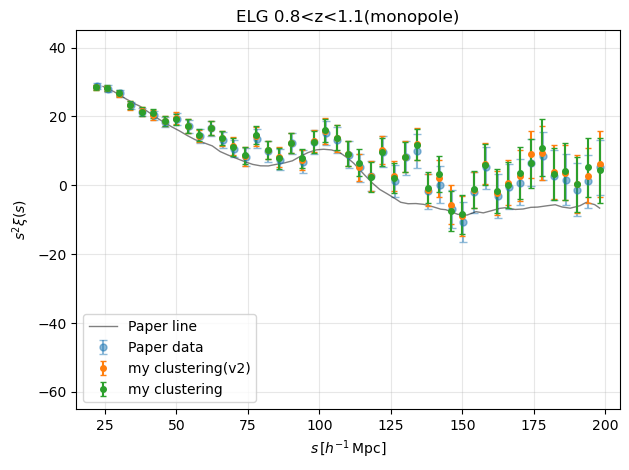

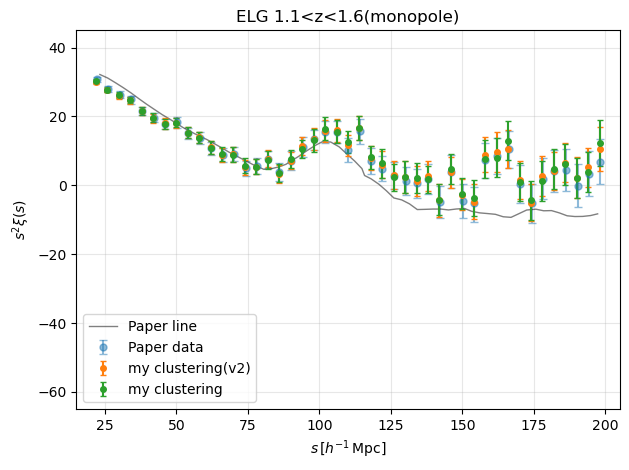

In [57]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_1_v2, yerr=s**2 * err1_v2,
    fmt="o", ms=4, capsize=2,
    label="my clustering(v2)"
)
plt.errorbar(
    s, s**2 * xi_mono_NS_1, yerr=s**2 * err1,
    fmt="o", ms=4, capsize=2,
    label="my clustering"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_2_v2, yerr=s**2 * err2_v2,
    fmt="o", ms=4, capsize=2,
    label="my clustering(v2)"
)
plt.errorbar(
    s, s**2 * xi_mono_NS_2, yerr=s**2 * err2,
    fmt="o", ms=4, capsize=2,
    label="my clustering"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

In [58]:
y_v1_1 = s**2 * xi_mono_NS_1
y_v2_1 = s**2 * xi_mono_NS_1_v2
y_v1_2 = s**2 * xi_mono_NS_2
y_v2_2 = s**2 * xi_mono_NS_2_v2

delta_v1_1 = y_v1_1 - y1
delta_v2_1 = y_v2_1 - y1
delta_v1_2 = y_v1_2 - y2
delta_v2_2 = y_v2_2 - y2

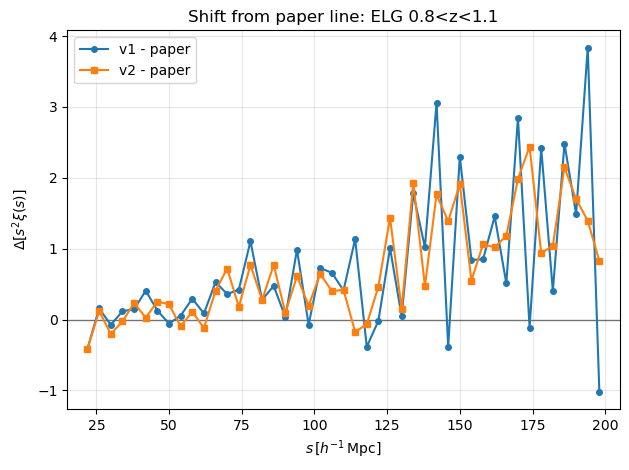

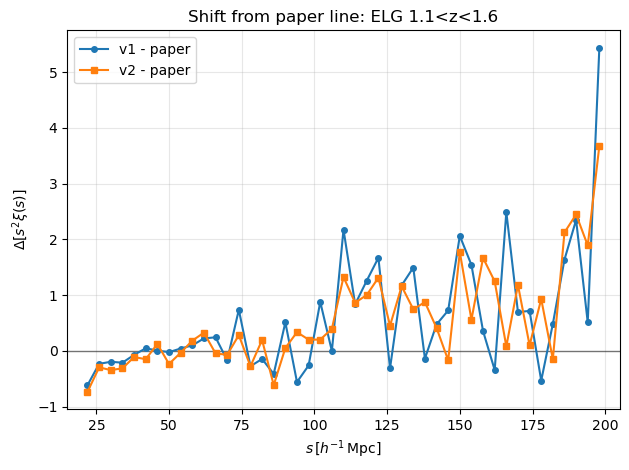

In [59]:
fig, ax = plt.subplots()
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.plot(s, delta_v1_1, "o-", ms=4, label="v1 - paper")
ax.plot(s, delta_v2_1, "s-", ms=4, label="v2 - paper")
ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta[s^2\xi(s)]$")
ax.set_title("Shift from paper line: ELG 0.8<z<1.1")
ax.set_xlim(15, 205)
ax.set_xticks(np.arange(25, 201, 25))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots()
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.plot(s, delta_v1_2, "o-", ms=4, label="v1 - paper")
ax.plot(s, delta_v2_2, "s-", ms=4, label="v2 - paper")
ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta[s^2\xi(s)]$")
ax.set_title("Shift from paper line: ELG 1.1<z<1.6")
ax.set_xlim(15, 205)
ax.set_xticks(np.arange(25, 201, 25))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

## pycorr

### v2

In [8]:
with np.load("/data/honke/xi0_NGC_z08_11_jk_v2.npz") as data_NGC1_v2:
    s_NGC1_v2    = data_NGC1_v2["s"]     
    xi_NGC1_v2   = data_NGC1_v2["xi"]     
    cov_NGC1_v2  = data_NGC1_v2["cov"]   
    err_NGC1_v2  = data_NGC1_v2["err"]   
    wD_NGC1_v2   = data_NGC1_v2["wD_tot"] 
    reg_NGC1_v2  = data_NGC1_v2["region"]

with np.load("/data/honke/xi0_NGC_z11_16_jk_v2.npz") as data_NGC2_v2:    
    s_NGC2_v2    = data_NGC2_v2["s"]     
    xi_NGC2_v2   = data_NGC2_v2["xi"]     
    cov_NGC2_v2  = data_NGC2_v2["cov"]   
    err_NGC2_v2  = data_NGC2_v2["err"]   
    wD_NGC2_v2   = data_NGC2_v2["wD_tot"] 
    reg_NGC2_v2  = data_NGC2_v2["region"] 


with np.load("/data/honke/xi0_SGC_z08_11_jk_v2.npz") as data_SGC1_v2:
    s_SGC1_v2    = data_SGC1_v2["s"]     
    xi_SGC1_v2   = data_SGC1_v2["xi"]     
    cov_SGC1_v2  = data_SGC1_v2["cov"]   
    err_SGC1_v2  = data_SGC1_v2["err"]   
    wD_SGC1_v2   = data_SGC1_v2["wD_tot"] 
    reg_SGC1_v2  = data_SGC1_v2["region"] 

with np.load("/data/honke/xi0_SGC_z11_16_jk_v2.npz") as data_SGC2_v2:
    s_SGC2_v2    = data_SGC2_v2["s"]     
    xi_SGC2_v2   = data_SGC2_v2["xi"]     
    cov_SGC2_v2  = data_SGC2_v2["cov"]   
    err_SGC2_v2  = data_SGC2_v2["err"]   
    wD_SGC2_v2   = data_SGC2_v2["wD_tot"] 
    reg_SGC2_v2  = data_SGC2_v2["region"] 

In [9]:
s_v2 = s_NGC1_v2

w_tot1_v2 = wD_NGC1_v2 + wD_SGC1_v2
cov_tot1_v2 = cov_NGC1_v2 + cov_SGC1_v2
xi_jack_NS1_v2 = (wD_NGC1_v2 * xi_NGC1_v2 + wD_SGC1_v2 * xi_SGC1_v2) / w_tot1_v2
cov1_v2 = (wD_NGC1_v2**2 * cov_NGC1_v2 + wD_SGC1_v2**2 * cov_SGC1_v2) / (w_tot1_v2**2)
err1_v2 = np.sqrt(np.diag(cov1_v2))

w_tot2_v2 = wD_NGC2_v2 + wD_SGC2_v2
cov_tot2_v2 = cov_NGC2_v2 + cov_SGC2_v2
xi_jack_NS2_v2 = (wD_NGC2_v2 * xi_NGC2_v2 + wD_SGC2_v2 * xi_SGC2_v2) / w_tot2_v2
cov2_v2 = (wD_NGC2_v2**2 * cov_NGC2_v2 + wD_SGC2_v2**2 * cov_SGC2_v2) / (w_tot2_v2**2)
err2_v2 = np.sqrt(np.diag(cov2_v2))

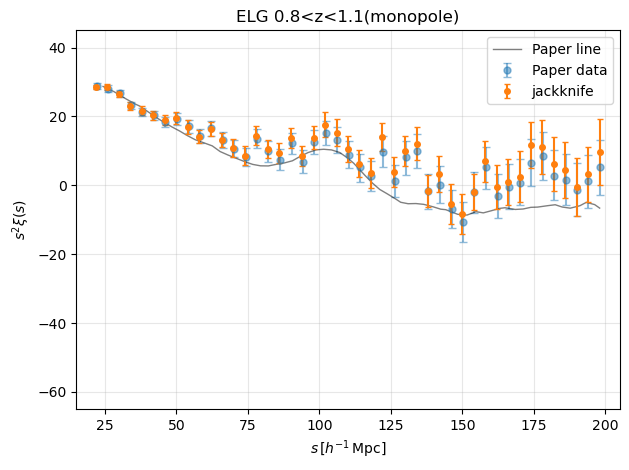

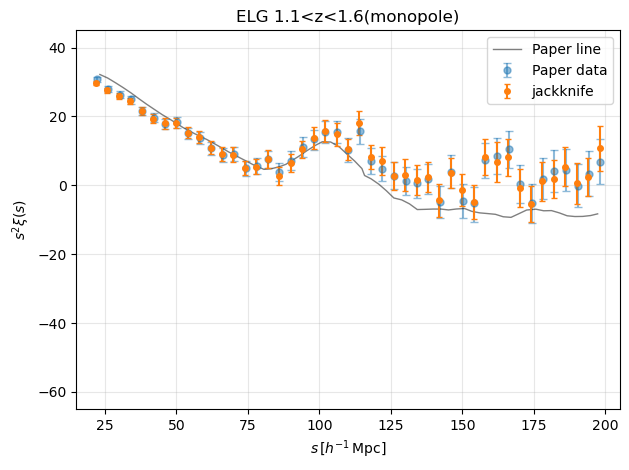

In [23]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_jack_NS1_v2, yerr=s**2 * err1_v2,
    fmt="o", ms=4, capsize=2,
    label="jackknife"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_jack_NS2_v2, yerr=s**2 * err2_v2,
    fmt="o", ms=4, capsize=2,
    label="jackknife"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

### v1

In [34]:
with np.load("/data/honke/xi0_NGC_z08_11_jk.npz") as data_NGC1:
    s_NGC1    = data_NGC1["s"]     
    xi_NGC1   = data_NGC1["xi"]     
    cov_NGC1  = data_NGC1["cov"]   
    err_NGC1  = data_NGC1["err"]   
    wD_NGC1   = data_NGC1["wD_tot"] 
    reg_NGC1  = data_NGC1["region"]

with np.load("/data/honke/xi0_NGC_z11_16_jk.npz") as data_NGC2:    
    s_NGC2    = data_NGC2["s"]     
    xi_NGC2   = data_NGC2["xi"]     
    cov_NGC2  = data_NGC2["cov"]   
    err_NGC2  = data_NGC2["err"]   
    wD_NGC2   = data_NGC2["wD_tot"] 
    reg_NGC2  = data_NGC2["region"] 


with np.load("/data/honke/xi0_SGC_z08_11_jk.npz") as data_SGC1:
    s_SGC1    = data_SGC1["s"]     
    xi_SGC1   = data_SGC1["xi"]     
    cov_SGC1  = data_SGC1["cov"]   
    err_SGC1  = data_SGC1["err"]   
    wD_SGC1   = data_SGC1["wD_tot"] 
    reg_SGC1  = data_SGC1["region"] 

with np.load("/data/honke/xi0_SGC_z11_16_jk.npz") as data_SGC2:
    s_SGC2    = data_SGC2["s"]     
    xi_SGC2   = data_SGC2["xi"]     
    cov_SGC2  = data_SGC2["cov"]   
    err_SGC2  = data_SGC2["err"]   
    wD_SGC2   = data_SGC2["wD_tot"] 
    reg_SGC2  = data_SGC2["region"] 

In [35]:
s = s_NGC1
w_tot1 = wD_NGC1 +wD_SGC1
cov_tot1 = cov_NGC1 + cov_SGC1
xi_jack_NS1 = (wD_NGC1 * xi_NGC1 + wD_SGC1 * xi_SGC1) / w_tot1
cov1 = (wD_NGC1**2 * cov_NGC1 + wD_SGC1**2 * cov_SGC1) / (w_tot1**2)
err1 = np.sqrt(np.diag(cov1))

w_tot2 = wD_NGC2 +wD_SGC2
cov_tot2 = cov_NGC2 + cov_SGC2
xi_jack_NS2 = (wD_NGC2 * xi_NGC2 + wD_SGC2 * xi_SGC2) / w_tot2
cov2 = (wD_NGC2**2 * cov_NGC2 + wD_SGC2**2 * cov_SGC2) / (w_tot2**2)
err2 = np.sqrt(np.diag(cov2))

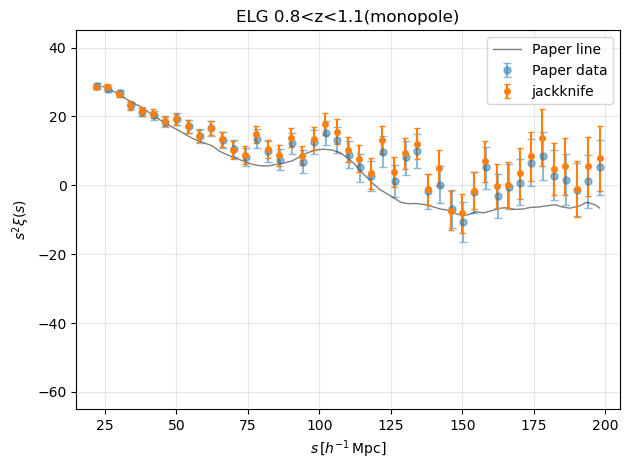

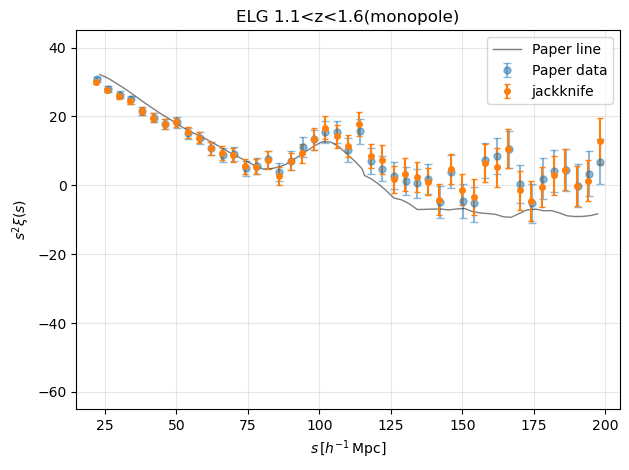

In [36]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_jack_NS1, yerr=s**2 * err1,
    fmt="o", ms=4, capsize=2,
    label="jackknife"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_jack_NS2, yerr=s**2 * err2,
    fmt="o", ms=4, capsize=2,
    label="jackknife"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

### compare

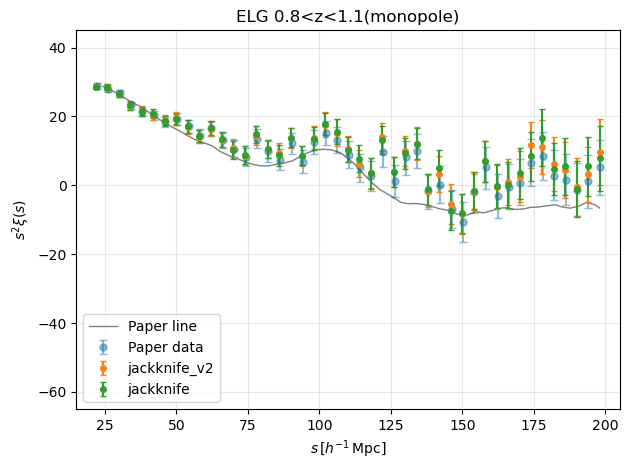

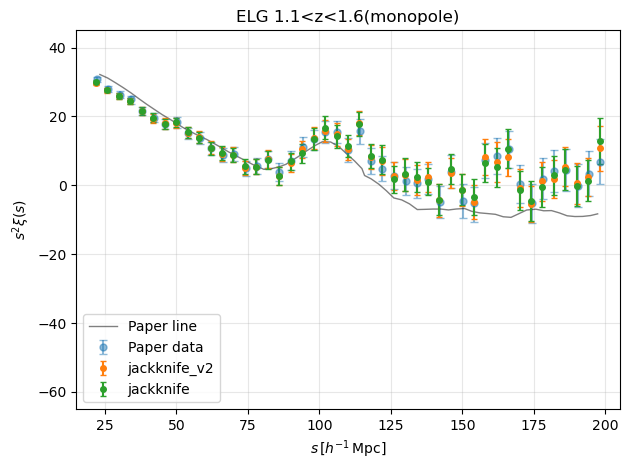

In [40]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_jack_NS1_v2, yerr=s**2 * err1_v2,
    fmt="o", ms=4, capsize=2,
    label="jackknife_v2"
)
plt.errorbar(
    s, s**2 * xi_jack_NS1, yerr=s**2 * err1,
    fmt="o", ms=4, capsize=2,
    label="jackknife"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_jack_NS2_v2, yerr=s**2 * err2_v2,
    fmt="o", ms=4, capsize=2,
    label="jackknife_v2"
)
plt.errorbar(
    s, s**2 * xi_jack_NS2, yerr=s**2 * err2,
    fmt="o", ms=4, capsize=2,
    label="jackknife"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

In [51]:
y_v1_jack_1 = s**2 * xi_jack_NS1
y_v2_jack_1 = s**2 * xi_jack_NS1_v2
y_v1_jack_2 = s**2 * xi_jack_NS2
y_v2_jack_2 = s**2 * xi_jack_NS2_v2

delta_v1_jack_1 = y_v1_jack_1 - y1
delta_v2_jack_1 = y_v2_jack_1 - y1
delta_v1_jack_2 = y_v1_jack_2 - y2
delta_v2_jack_2 = y_v2_jack_2 - y2

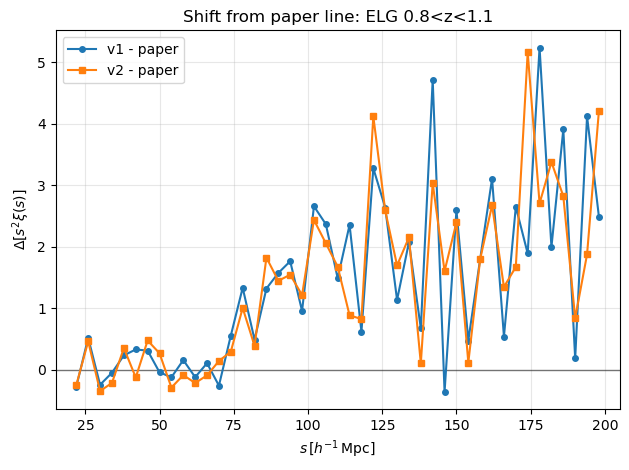

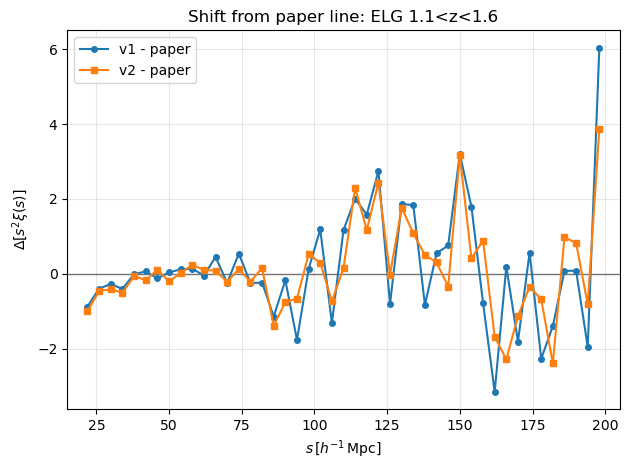

In [52]:
fig, ax = plt.subplots()
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.plot(s, delta_v1_jack_1, "o-", ms=4, label="v1 - paper")
ax.plot(s, delta_v2_jack_1, "s-", ms=4, label="v2 - paper")
ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta[s^2\xi(s)]$")
ax.set_title("Shift from paper line: ELG 0.8<z<1.1")
ax.set_xlim(15, 205)
ax.set_xticks(np.arange(25, 201, 25))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots()
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.plot(s, delta_v1_jack_2, "o-", ms=4, label="v1 - paper")
ax.plot(s, delta_v2_jack_2, "s-", ms=4, label="v2 - paper")
ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta[s^2\xi(s)]$")
ax.set_title("Shift from paper line: ELG 1.1<z<1.6")
ax.set_xlim(15, 205)
ax.set_xticks(np.arange(25, 201, 25))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

## DDRR vs jack

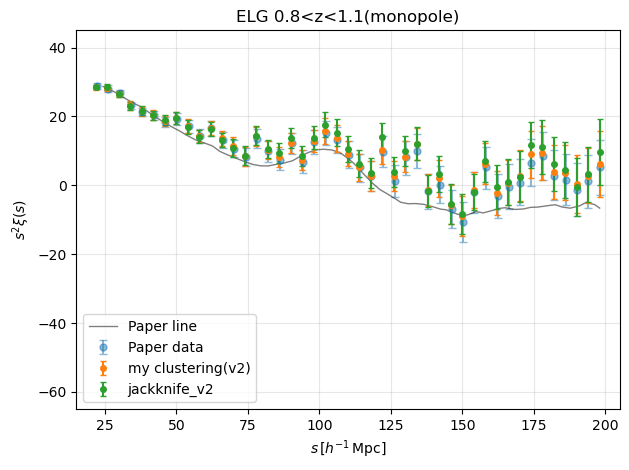

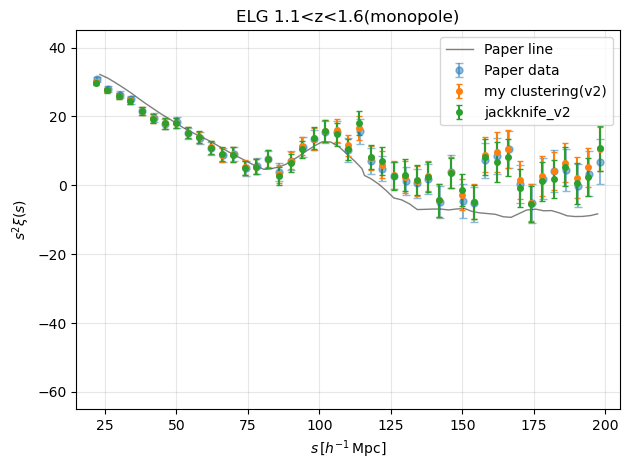

In [60]:
fig, ax = plt.subplots()
ax.errorbar(x1, y1, yerr=[yerr_lo1, yerr_up1],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line1["x"], line1["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_1_v2, yerr=s**2 * err1_v2,
    fmt="o", ms=4, capsize=2,
    label="my clustering(v2)"
)
plt.errorbar(
    s, s**2 * xi_jack_NS1_v2, yerr=s**2 * err1_v2,
    fmt="o", ms=4, capsize=2,
    label="jackknife_v2"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 0.8<z<1.1(monopole)")
plt.tight_layout()

fig, ax = plt.subplots()
ax.errorbar(x2, y2, yerr=[yerr_lo2, yerr_up2],
            fmt="o", ms=5, capsize=3,alpha=0.5, 
            label="Paper data")

ax.plot(line2["x"], line2["y"], 
        lw=1, color="black", alpha=0.5, label="Paper line")

plt.errorbar(
    s, s**2 * xi_mono_NS_2_v2, yerr=s**2 * err2_v2,
    fmt="o", ms=4, capsize=2,
    label="my clustering(v2)"
)
plt.errorbar(
    s, s**2 * xi_jack_NS2_v2, yerr=s**2 * err2_v2,
    fmt="o", ms=4, capsize=2,
    label="jackknife_v2"
)
# plt.xscale("log")
plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$s^2\xi(s)$")
ax.set_xlim(15, 205)
ax.set_ylim(-65, 45)
ax.set_xticks(np.arange(25, 201, 25))
ax.set_yticks(np.arange(-60, 41, 20))
ax.grid(alpha=0.3)
ax.legend()
plt.title("ELG 1.1<z<1.6(monopole)")
plt.tight_layout()
plt.show()

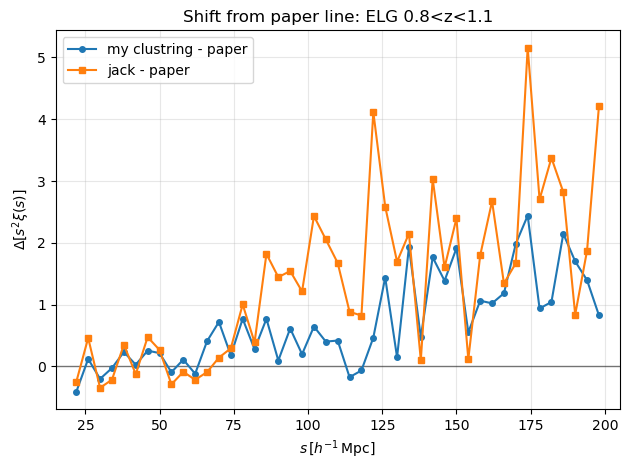

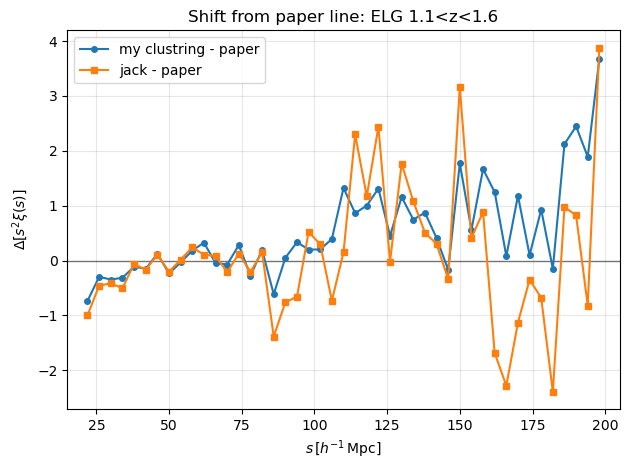

In [62]:
fig, ax = plt.subplots()
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.plot(s, delta_v2_1, "o-", ms=4, label="my clustring - paper")
ax.plot(s, delta_v2_jack_1, "s-", ms=4, label="jack - paper")
ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta[s^2\xi(s)]$")
ax.set_title("Shift from paper line: ELG 0.8<z<1.1")
ax.set_xlim(15, 205)
ax.set_xticks(np.arange(25, 201, 25))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots()
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.plot(s, delta_v2_2, "o-", ms=4, label="my clustring - paper")
ax.plot(s, delta_v2_jack_2, "s-", ms=4, label="jack - paper")
ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta[s^2\xi(s)]$")
ax.set_title("Shift from paper line: ELG 1.1<z<1.6")
ax.set_xlim(15, 205)
ax.set_xticks(np.arange(25, 201, 25))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()